## Breast Cancer Detection from Mammograms — PRD-Aligned End-to-End Notebook



## Import Libraries

In [73]:
import os
import random
import json
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from PIL import Image

# ---------- PyTorch ----------
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)

# ---------- Torchvision ----------
from torchvision import (
    transforms,
    models
)

# ---------- Scikit-learn ----------
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils import resample
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    brier_score_loss
)

# ---------- Model Saving ----------
import copy

# ---------- Reproducibility ----------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ---------- Device ----------
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", device)
print("Libraries Loaded Successfully")


PyTorch version: 2.10.0+cu128
Device: cuda
Libraries Loaded Successfully


## Data Path

In [74]:
dataset_path = "/kaggle/input/datasets/remekkinas/rsna-breast-cancer-detection-poi-images"

folder_path = os.path.join(
    dataset_path,
    "bc_1280_train_lut"
)

print("Dataset path:", dataset_path)
print("Images folder:", folder_path)

Dataset path: /kaggle/input/datasets/remekkinas/rsna-breast-cancer-detection-poi-images
Images folder: /kaggle/input/datasets/remekkinas/rsna-breast-cancer-detection-poi-images/bc_1280_train_lut


In [75]:
files = os.listdir(folder_path)
print("Number of files:", len(files))


Number of files: 54706


## Dataset Understanding

In [76]:
from collections import Counter

extensions = Counter(
    Path(file).suffix.lower()
    for file in files
)

print(extensions)

Counter({'.png': 54706})


In [77]:
data = []
skipped = 0

for file in files:

    stem = Path(file).stem
    parts = stem.split("_")

    if len(parts) == 2:
        data.append({
            "patient_id": parts[0],
            "image_id": parts[1],
            "image_name": file
        })
    else:
        skipped += 1

df = pd.DataFrame(data)

print("Shape:", df.shape)
print("Skipped filenames (unexpected pattern):", skipped)
print(df.head())


Shape: (54706, 3)
Skipped filenames (unexpected pattern): 0
  patient_id    image_id            image_name
0      10289  1390886438  10289_1390886438.png
1      21915  1598001440  21915_1598001440.png
2       5123  1805049792   5123_1805049792.png
3       2821   494034978    2821_494034978.png
4      47058   338044000   47058_338044000.png


In [78]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

Rows: 54706
Columns: 3

Columns:
['patient_id', 'image_id', 'image_name']


In [79]:
print("Unique patients:", df["patient_id"].nunique())
print("Unique images:", df["image_id"].nunique())

Unique patients: 11913
Unique images: 54706


In [80]:
images_per_patient = df["patient_id"].value_counts()

print(images_per_patient.describe())

count    11913.000000
mean         4.592126
std          1.133216
min          4.000000
25%          4.000000
50%          4.000000
75%          5.000000
max         14.000000
Name: count, dtype: float64


In [81]:
images_per_patient_counts = images_per_patient.reset_index()
images_per_patient_counts.columns = ["patient_id", "num_images"]

fig = px.histogram(
    images_per_patient_counts,
    x="num_images",
    nbins=20,
    title="Number of Images per Patient",
    labels={
        "num_images": "Number of Images",
        "count": "Number of Patients"
    }
)

fig.show()


In [82]:
sample_files = files[:100]

sizes = []

for file in sample_files:

    image_path = os.path.join(folder_path, file)

    with Image.open(image_path) as img:
        sizes.append(img.size)

sizes_df = pd.DataFrame(
    sizes,
    columns=["Width", "Height"]
)

print(sizes_df.describe())

             Width  Height
count   100.000000   100.0
mean    707.070000  1280.0
std     170.622997     0.0
min     389.000000  1280.0
25%     584.750000  1280.0
50%     678.500000  1280.0
75%     816.250000  1280.0
max    1181.000000  1280.0


In [83]:
print(
    sizes_df.value_counts().head(20)
)

Width  Height
498    1280      2
550    1280      2
600    1280      2
673    1280      2
816    1280      2
757    1280      2
739    1280      2
609    1280      2
632    1280      2
435    1280      1
417    1280      1
528    1280      1
538    1280      1
541    1280      1
545    1280      1
564    1280      1
565    1280      1
568    1280      1
569    1280      1
572    1280      1
Name: count, dtype: int64


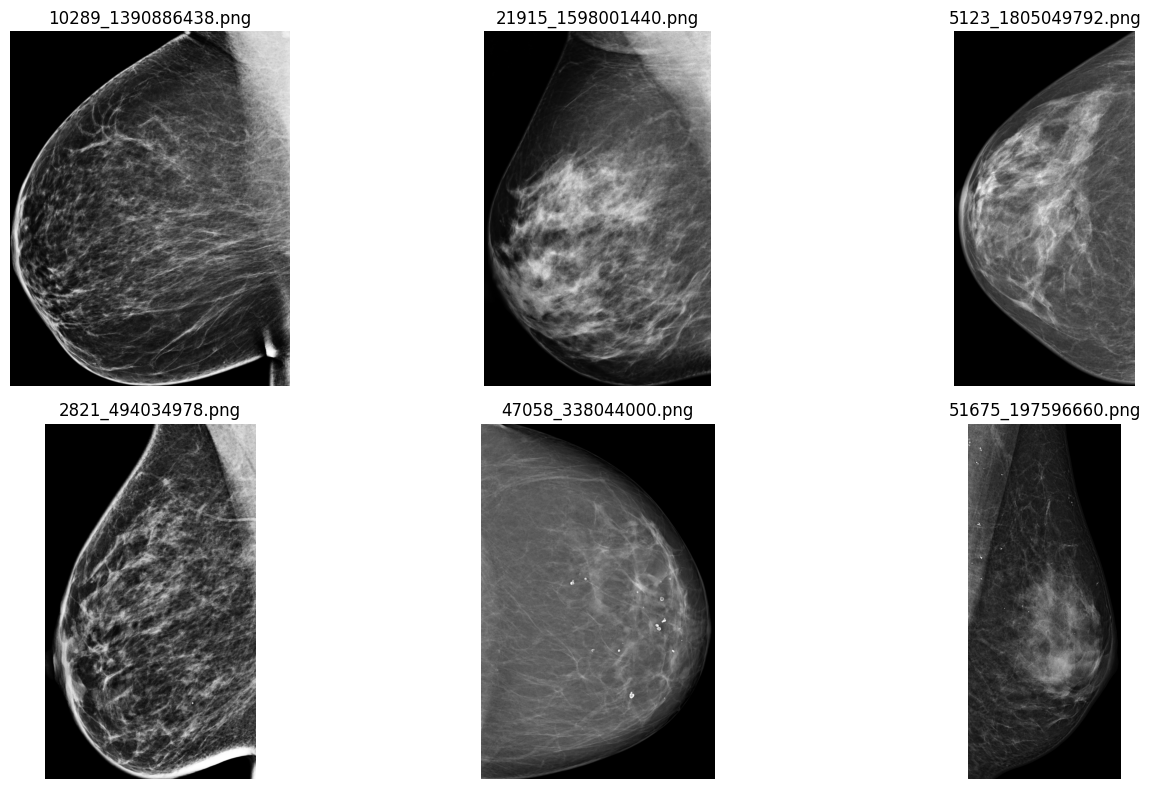

In [84]:
sample_files = files[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, file in zip(axes.ravel(), sample_files):

    image_path = os.path.join(folder_path, file)

    img = Image.open(image_path)

    ax.imshow(img, cmap="gray")
    ax.set_title(file)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Metadata Loading

In [85]:
train_csv_path = "/kaggle/input/competitions/rsna-breast-cancer-detection/train.csv"

metadata = pd.read_csv(train_csv_path)

print("Shape:", metadata.shape)
print(metadata.columns.tolist())

display(metadata.head())

Shape: (54706, 14)
['site_id', 'patient_id', 'image_id', 'laterality', 'view', 'age', 'cancer', 'biopsy', 'invasive', 'BIRADS', 'implant', 'density', 'machine_id', 'difficult_negative_case']


,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case
0,2,10006,462822612,L,CC,61.0,0,0,0,NaN,0,NaN,29,False
1,2,10006,1459541791,L,MLO,61.0,0,0,0,NaN,0,NaN,29,False
2,2,10006,1864590858,R,MLO,61.0,0,0,0,NaN,0,NaN,29,False
3,2,10006,1874946579,R,CC,61.0,0,0,0,NaN,0,NaN,29,False
4,2,10011,220375232,L,CC,55.0,0,0,0,0.0,0,NaN,21,True


In [86]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54706 entries, 0 to 54705
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   site_id                  54706 non-null  int64  
 1   patient_id               54706 non-null  int64  
 2   image_id                 54706 non-null  int64  
 3   laterality               54706 non-null  object 
 4   view                     54706 non-null  object 
 5   age                      54669 non-null  float64
 6   cancer                   54706 non-null  int64  
 7   biopsy                   54706 non-null  int64  
 8   invasive                 54706 non-null  int64  
 9   BIRADS                   26286 non-null  float64
 10  implant                  54706 non-null  int64  
 11  density                  29470 non-null  object 
 12  machine_id               54706 non-null  int64  
 13  difficult_negative_case  54706 non-null  bool   
dtypes: bool(1), float64(2)

In [87]:
print(metadata.isnull().sum())

site_id                        0
patient_id                     0
image_id                       0
laterality                     0
view                           0
age                           37
cancer                         0
biopsy                         0
invasive                       0
BIRADS                     28420
implant                        0
density                    25236
machine_id                     0
difficult_negative_case        0
dtype: int64


In [88]:
df["patient_id"] = df["patient_id"].astype(str)
df["image_id"] = df["image_id"].astype(str)

metadata["patient_id"] = metadata["patient_id"].astype(str)
metadata["image_id"] = metadata["image_id"].astype(str)

## Metadata matching

In [89]:
duplicates = metadata.duplicated(
    subset=["patient_id", "image_id"]
).sum()

print("Duplicate patient_id + image_id:", duplicates)

Duplicate patient_id + image_id: 0


In [90]:
image_df = df.copy()

In [91]:
merged_df = image_df.merge(
    metadata,
    on=["patient_id", "image_id"],
    how="inner"
)

## Exploratory Data Analysis

In [92]:
missing_df = (
    merged_df.isnull()
    .sum()
    .reset_index()
)

missing_df.columns = ["Column", "Missing"]

missing_df["Missing_%"] = (
    missing_df["Missing"] / len(merged_df) * 100
).round(2)

missing_df = missing_df.sort_values(
    "Missing",
    ascending=False
)

display(missing_df)

,Column,Missing,Missing_%
10,BIRADS,28420,51.95
12,density,25236,46.13
6,age,37,0.07
2,image_name,0,0.00
3,site_id,0,0.00
1,image_id,0,0.00
0,patient_id,0,0.00
5,view,0,0.00
4,laterality,0,0.00
8,biopsy,0,0.00


In [93]:
print("Original POI images:", len(image_df))
print("After merge:", len(merged_df))
print("Columns:", merged_df.columns.tolist())
print(merged_df.shape)

Original POI images: 54706
After merge: 54706
Columns: ['patient_id', 'image_id', 'image_name', 'site_id', 'laterality', 'view', 'age', 'cancer', 'biopsy', 'invasive', 'BIRADS', 'implant', 'density', 'machine_id', 'difficult_negative_case']
(54706, 15)


In [94]:
matched = len(merged_df)
total_images = len(image_df)

print("Total POI images:", total_images)
print("Matched images:", matched)
print("Unmatched images:", total_images - matched)

print(
    "Match percentage:",
    round(matched / total_images * 100, 2),
    "%"
)

Total POI images: 54706
Matched images: 54706
Unmatched images: 0
Match percentage: 100.0 %


In [95]:
print(merged_df["cancer"].value_counts())

cancer
0    53548
1     1158
Name: count, dtype: int64


In [96]:
print(
    merged_df["cancer"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

cancer
0    97.88
1     2.12
Name: proportion, dtype: float64


## Class Distribution

In [97]:
cancer_counts = merged_df["cancer"].value_counts().reset_index()
cancer_counts.columns = ["cancer", "count"]

fig = px.bar(
    cancer_counts,
    x="cancer",
    y="count",
    title="Cancer Class Distribution (image-level)",
    labels={
        "cancer": "Cancer",
        "count": "Number of Images"
    },
    text="count"
)

fig.show()

print(
    "Positive class prevalence: "
    f"{merged_df['cancer'].mean() * 100:.2f}%"
)


Positive class prevalence: 2.12%


In [98]:
display(
    merged_df[
        [
            "patient_id",
            "image_id",
            "image_name",
            "cancer"
        ]
    ].head(10)
)
display(merged_df.head())

,patient_id,image_id,image_name,cancer
0,10289,1390886438,10289_1390886438.png,0
1,21915,1598001440,21915_1598001440.png,0
2,5123,1805049792,5123_1805049792.png,0
3,2821,494034978,2821_494034978.png,0
4,47058,338044000,47058_338044000.png,0
5,51675,197596660,51675_197596660.png,0
6,36714,413497321,36714_413497321.png,0
7,46319,1004428353,46319_1004428353.png,0
8,49299,1137424604,49299_1137424604.png,0
9,4356,784715438,4356_784715438.png,0


,patient_id,image_id,image_name,site_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case
0,10289,1390886438,10289_1390886438.png,1,R,MLO,62.0,0,0,0,1.0,0,B,49,False
1,21915,1598001440,21915_1598001440.png,1,R,MLO,49.0,0,0,0,1.0,0,C,210,False
2,5123,1805049792,5123_1805049792.png,2,R,CC,58.0,0,0,0,NaN,0,NaN,21,False
3,2821,494034978,2821_494034978.png,1,R,MLO,53.0,0,0,0,NaN,0,B,49,False
4,47058,338044000,47058_338044000.png,2,L,CC,66.0,0,0,0,NaN,0,NaN,21,False


In [99]:
fig = px.histogram(
    merged_df,
    x="age",
    nbins=30,
    title="Age Distribution",
    labels={"age": "Age"}
)

fig.show()

In [100]:
merged_df ["age"].describe()

count    54669.000000
mean        58.543928
std         10.050884
min         26.000000
25%         51.000000
50%         59.000000
75%         66.000000
max         89.000000
Name: age, dtype: float64

In [101]:
fig = px.histogram(
    merged_df,
    x="age",
    color="cancer",
    nbins=30,
    barmode="overlay",
    title="Age Distribution by Cancer Status"
)

fig.show()

In [102]:
print(merged_df["laterality"].value_counts())

laterality
R    27439
L    27267
Name: count, dtype: int64


In [103]:
print(merged_df["view"].value_counts())

view
MLO    27903
CC     26765
AT        19
LM        10
ML         8
LMO        1
Name: count, dtype: int64


In [104]:
view_counts = merged_df["view"].value_counts().reset_index()
view_counts.columns = ["view", "count"]

fig = px.bar(
    view_counts,
    x="view",
    y="count",
    title="Mammogram View Distribution"
)

fig.show()


In [105]:
print(merged_df["density"].value_counts(dropna=False))

density
NaN    25236
B      12651
C      12175
A       3105
D       1539
Name: count, dtype: int64


In [106]:
density_cancer = (
    merged_df
    .assign(density=merged_df["density"].fillna("Missing"))
    .groupby(["density", "cancer"])
    .size()
    .reset_index(name="count")
)

fig = px.bar(
    density_cancer,
    x="density",
    y="count",
    color="cancer",
    barmode="group",
    title="Cancer Distribution by Breast Density"
)

fig.show()

In [107]:
density_df = (
    merged_df["density"]
    .fillna("Missing")
    .value_counts()
    .reset_index()
)

density_df.columns = ["Density", "Count"]

fig = px.bar(
    density_df,
    x="Density",
    y="Count",
    title="Breast Density Distribution",
    text="Count"
)

fig.show()

## Patient Distribution

In [108]:
images_per_patient = (
    merged_df
    .groupby("patient_id")
    .size()
)

print(images_per_patient.describe())

count    11913.000000
mean         4.592126
std          1.133216
min          4.000000
25%          4.000000
50%          4.000000
75%          5.000000
max         14.000000
dtype: float64


In [109]:
fig = px.histogram(
    images_per_patient,
    nbins=20,
    title="Number of Images per Patient"
)

fig.show()

In [110]:
print("Total patients:", merged_df["patient_id"].nunique())
print("Total images:", len(merged_df))

print("\nCancer by patient:")
patient_cancer = (
    merged_df
    .groupby("patient_id")["cancer"]
    .max()
)

print(patient_cancer.value_counts())

Total patients: 11913
Total images: 54706

Cancer by patient:
cancer
0    11427
1      486
Name: count, dtype: int64


In [111]:
patient_label_check = (
    merged_df
    .groupby("patient_id")["cancer"]
    .nunique()
)

print(
    patient_label_check.value_counts()
)

cancer
1    11433
2      480
Name: count, dtype: int64


In [112]:
print("Image-level cancer:")
print(merged_df["cancer"].value_counts(dropna=False))

print("\nUnique cancer values:")
print(merged_df["cancer"].unique())

Image-level cancer:
cancer
0    53548
1     1158
Name: count, dtype: int64

Unique cancer values:
[0 1]


## Image Analysis

In [113]:
print("\nPatient-level cancer:")
patient_cancer = (
    merged_df
    .groupby("patient_id")["cancer"]
    .agg(["min", "max", "nunique"])
)

display(patient_cancer.head())

print("\nPatients with more than one cancer label:")
print((patient_cancer["nunique"] > 1).sum())


Patient-level cancer:


,min,max,nunique
patient_id,,,
10006,0,0,1
10011,0,0,1
10025,0,0,1
10038,0,0,1
10042,0,0,1



Patients with more than one cancer label:
480


In [114]:
patient_cancer = (
    merged_df
    .groupby("patient_id")["cancer"]
    .agg(["min", "max", "nunique", "count"])
)

display(patient_cancer.head(10))

,min,max,nunique,count
patient_id,,,,
10006,0,0,1,4
10011,0,0,1,4
10025,0,0,1,4
10038,0,0,1,4
10042,0,0,1,5
10048,0,0,1,4
10049,0,0,1,6
10050,0,0,1,4
10051,0,0,1,4


In [115]:
print("Patients with only cancer=0:")
print(((patient_cancer["min"] == 0) & (patient_cancer["max"] == 0)).sum())

print("\nPatients with only cancer=1:")
print(((patient_cancer["min"] == 1) & (patient_cancer["max"] == 1)).sum())

print("\nPatients with both 0 and 1:")
print(
    ((patient_cancer["min"] == 0) &
     (patient_cancer["max"] == 1)).sum()
)

Patients with only cancer=0:
11427

Patients with only cancer=1:
6

Patients with both 0 and 1:
480


## Bounding Box Check

In [116]:
bbox_files = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        lower_name = file.lower()

        if any(keyword in lower_name for keyword in [
            "bbox",
            "bounding",
            "annotation",
            "box"
        ]):

            bbox_files.append(
                os.path.join(root, file)
            )

print("Bounding-box related files:")

if bbox_files:

    for file in bbox_files:
        print(file)

else:
    print("No separate bounding-box annotation file found.")

Bounding-box related files:
No separate bounding-box annotation file found.


## Patient-Level Train / Validation / Test Split

In [117]:
patient_label = (
    merged_df.groupby("patient_id")["cancer"]
    .max()
)

patients = patient_label.index.to_numpy()
patient_y = patient_label.to_numpy()

train_patients, temp_patients, train_y, temp_y = train_test_split(
    patients,
    patient_y,
    test_size=0.20,
    random_state=SEED,
    stratify=patient_y
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_y
)

print("Train patients:", len(train_patients))
print("Validation patients:", len(val_patients))
print("Test patients:", len(test_patients))


Train patients: 9530
Validation patients: 1191
Test patients: 1192


In [118]:
train_df = merged_df[
    merged_df["patient_id"].isin(train_patients)
].copy()

val_df = merged_df[
    merged_df["patient_id"].isin(val_patients)
].copy()

test_df = merged_df[
    merged_df["patient_id"].isin(test_patients)
].copy()

print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

Train images: 43800
Validation images: 5491
Test images: 5415


## Leakage Check

In [119]:
train_set = set(train_df["patient_id"])
val_set = set(val_df["patient_id"])
test_set = set(test_df["patient_id"])

print("Train ∩ Validation:", len(train_set & val_set))
print("Train ∩ Test:", len(train_set & test_set))
print("Validation ∩ Test:", len(val_set & test_set))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [120]:
print("TRAIN")
print(train_df["cancer"].value_counts())
print()

print("VALIDATION")
print(val_df["cancer"].value_counts())
print()

print("TEST")
print(test_df["cancer"].value_counts())

TRAIN
cancer
0    42878
1      922
Name: count, dtype: int64

VALIDATION
cancer
0    5376
1     115
Name: count, dtype: int64

TEST
cancer
0    5294
1     121
Name: count, dtype: int64


In [121]:
for name, data in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    
    print(f"\n{name}")
    
    print(
        data["cancer"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )


Train
cancer
0    97.89
1     2.11
Name: proportion, dtype: float64

Validation
cancer
0    97.91
1     2.09
Name: proportion, dtype: float64

Test
cancer
0    97.77
1     2.23
Name: proportion, dtype: float64


In [122]:
from PIL import Image
sample_path = os.path.join(
    folder_path,
    train_df.iloc[0]["image_name"]
)

img = Image.open(sample_path)

print("Image size:", img.size)
print("Image mode:", img.mode)

Image size: (1006, 1280)
Image mode: L


In [123]:
from collections import Counter

image_sizes = []

for filename in merged_df["image_name"].sample(1000, random_state=42):
    path = os.path.join(folder_path, filename)
    with Image.open(path) as img:
        image_sizes.append(img.size)

size_counts = Counter(image_sizes)

print("Different image sizes:", len(size_counts))
print("\nMost common sizes:")
print(size_counts.most_common(10))

Different image sizes: 500

Most common sizes:
[((619, 1280), 8), ((635, 1280), 7), ((637, 1280), 7), ((633, 1280), 7), ((601, 1280), 7), ((572, 1280), 6), ((599, 1280), 6), ((808, 1280), 6), ((609, 1280), 6), ((693, 1280), 5)]


## Preprocessing

In [124]:
from torchvision.transforms import functional as TF

IMG_SIZE = 512  

class ResizeWithPad:
    """Resize preserving aspect ratio, then pad to a square canvas.
    Used everywhere (train/val/test/Grad-CAM) so every visualization and
    prediction sees the exact same geometry the model was trained on."""

    def __init__(self, size, fill=0):
        self.size = size
        self.fill = fill

    def __call__(self, img):
        w, h = img.size

        scale = self.size / max(w, h)

        new_w = int(w * scale)
        new_h = int(h * scale)

        img = img.resize((new_w, new_h), resample=Image.BILINEAR)

        pad_left = (self.size - new_w) // 2
        pad_top = (self.size - new_h) // 2

        pad_right = self.size - new_w - pad_left
        pad_bottom = self.size - new_h - pad_top

        return TF.pad(
            img,
            [pad_left, pad_top, pad_right, pad_bottom],
            fill=self.fill
        )


train_transform = transforms.Compose([
    ResizeWithPad(IMG_SIZE),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_test_transform = transforms.Compose([
    ResizeWithPad(IMG_SIZE),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms updated successfully.")
print("Image size:", IMG_SIZE)


Transforms updated successfully.
Image size: 512


In [125]:
VIEW_CLASSES = sorted(
    merged_df["view"].fillna("Missing").astype(str).unique()
)
DENSITY_CLASSES = sorted(
    merged_df["density"].fillna("Missing").astype(str).unique()
)

view_to_idx = {value: idx for idx, value in enumerate(VIEW_CLASSES)}
density_to_idx = {value: idx for idx, value in enumerate(DENSITY_CLASSES)}

print("View classes:", VIEW_CLASSES)
print("Density classes:", DENSITY_CLASSES)


class BreastCancerDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        transform=None,
        view_to_idx=None,
        density_to_idx=None
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.view_to_idx = view_to_idx
        self.density_to_idx = density_to_idx

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = os.path.join(
            self.image_dir,
            row["image_name"]
        )

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        view = str(row["view"]) if pd.notna(row["view"]) else "Missing"
        density = str(row["density"]) if pd.notna(row["density"]) else "Missing"

        view = self.view_to_idx[view]
        density = self.density_to_idx[density]

        label = float(row["cancer"])

        return (
            image,
            torch.tensor(view, dtype=torch.long),
            torch.tensor(density, dtype=torch.long),
            torch.tensor(label, dtype=torch.float32)
        )


View classes: ['AT', 'CC', 'LM', 'LMO', 'ML', 'MLO']
Density classes: ['A', 'B', 'C', 'D', 'Missing']


In [126]:
train_dataset = BreastCancerDataset(
    train_df,
    folder_path,
    transform=train_transform,
    view_to_idx=view_to_idx,
    density_to_idx=density_to_idx
)

val_dataset = BreastCancerDataset(
    val_df,
    folder_path,
    transform=val_test_transform,
    view_to_idx=view_to_idx,
    density_to_idx=density_to_idx
)

test_dataset = BreastCancerDataset(
    test_df,
    folder_path,
    transform=val_test_transform,
    view_to_idx=view_to_idx,
    density_to_idx=density_to_idx
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))


Train: 43800
Validation: 5491
Test: 5415


In [127]:
BATCH_SIZE = 32

train_labels_for_sampler = train_df["cancer"].to_numpy()
class_sample_count = np.bincount(train_labels_for_sampler)
sample_weights = 1.0 / class_sample_count[train_labels_for_sampler]
sample_weights = torch.as_tensor(sample_weights, dtype=torch.double)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)


In [128]:
images, views, densities, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Views shape:", views.shape)
print("Densities shape:", densities.shape)
print("Labels shape:", labels.shape)
print("Views:", views[:10])
print("Densities:", densities[:10])
print("Labels:", labels[:10])


Images shape: torch.Size([32, 3, 512, 512])
Views shape: torch.Size([32])
Densities shape: torch.Size([32])
Labels shape: torch.Size([32])
Views: tensor([1, 1, 5, 1, 5, 1, 1, 5, 5, 5])
Densities: tensor([2, 0, 1, 1, 1, 3, 4, 4, 2, 4])
Labels: tensor([0., 0., 1., 0., 0., 1., 0., 0., 1., 1.])


## Class Imbalance Handling

In [129]:
class_counts = train_df["cancer"].value_counts().sort_index()

print(class_counts)

cancer
0    42878
1      922
Name: count, dtype: int64


In [130]:
num_negative = class_counts[0]
num_positive = class_counts[1]

pos_weight = num_negative / num_positive

print("Negative:", num_negative)
print("Positive:", num_positive)
print("Positive weight:", pos_weight)

Negative: 42878
Positive: 922
Positive weight: 46.50542299349241


In [131]:
pos_weight_tensor = torch.tensor(
    [pos_weight],
    dtype=torch.float32
).to(device)

## Feature Extractor / Backbone

In [132]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class EfficientNetMultiTask(nn.Module):
    """
    Image-only multi-task model.

    One mammogram image is used to predict:
      1) Cancer / No Cancer
      2) Mammogram View
      3) Breast Density

    View and Density are auxiliary prediction tasks, so they are
    automatically inferred from the image at inference time.
    """

    def __init__(self, num_views, num_densities):
        super().__init__()

        weights = models.EfficientNet_B0_Weights.DEFAULT
        self.backbone = models.efficientnet_b0(weights=weights)

        image_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        self.cancer_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(image_features, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

        self.view_head = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(image_features, 128),
            nn.ReLU(),
            nn.Linear(128, num_views)
        )

        self.density_head = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(image_features, 128),
            nn.ReLU(),
            nn.Linear(128, num_densities)
        )

    def forward(self, images):

        image_features = self.backbone(images)

        cancer_logit = self.cancer_head(image_features)
        view_logits = self.view_head(image_features)
        density_logits = self.density_head(image_features)

        return cancer_logit, view_logits, density_logits


model = EfficientNetMultiTask(
    num_views=len(VIEW_CLASSES),
    num_densities=len(DENSITY_CLASSES)
).to(device)

print("Device:", device)
print("Model loaded successfully!")
print("Number of view classes:", len(VIEW_CLASSES))
print("Number of density classes:", len(DENSITY_CLASSES))


Device: cuda
Model loaded successfully!
Number of view classes: 6
Number of density classes: 5


##  Transfer Learning Model — EfficientNet

In [133]:
# Unfreeze the EfficientNet backbone
for param in model.backbone.features.parameters():
    param.requires_grad = True

# Keep all three prediction heads trainable
for param in model.cancer_head.parameters():
    param.requires_grad = True

for param in model.view_head.parameters():
    param.requires_grad = True

for param in model.density_head.parameters():
    param.requires_grad = True

cancer_criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor
)

view_criterion = nn.CrossEntropyLoss()
density_criterion = nn.CrossEntropyLoss()

# Keep the auxiliary tasks from dominating the cancer objective.
CANCER_LOSS_WEIGHT = 1.0
VIEW_LOSS_WEIGHT = 0.2
DENSITY_LOSS_WEIGHT = 0.2

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("Multi-task fine-tuning mode ready.")
print(
    "Trainable parameters:",
    sum(p.numel() for p in model.parameters() if p.requires_grad)
)


Multi-task fine-tuning mode ready.
Trainable parameters: 4501000


In [134]:
model = model.to(device)

print("Model device:", next(model.parameters()).device)

Model device: cuda:0


In [135]:
print(
    "Backbone trainable:",
    any(
        p.requires_grad
        for p in model.backbone.features.parameters()
    )
)

print(
    "Cancer head trainable:",
    any(
        p.requires_grad
        for p in model.cancer_head.parameters()
    )
)

print(
    "View head trainable:",
    any(
        p.requires_grad
        for p in model.view_head.parameters()
    )
)

print(
    "Density head trainable:",
    any(
        p.requires_grad
        for p in model.density_head.parameters()
    )
)


Backbone trainable: True
Cancer head trainable: True
View head trainable: True
Density head trainable: True


In [138]:
checkpoint_path = "/kaggle/working/checkpoint_multitask.pth"

if os.path.exists(checkpoint_path):

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False
    )

    model.load_state_dict(
        checkpoint["model_state_dict"],
        strict=True
    )

    optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )

    start_epoch = checkpoint["epoch"]
    best_val_auc = checkpoint.get("best_val_auc", 0.0)
    best_val_pr_auc = checkpoint.get("best_val_pr_auc", 0.0)
    best_threshold = checkpoint.get("best_threshold", 0.5)
    best_model = copy.deepcopy(model.state_dict())

    print("Multi-task checkpoint loaded successfully.")
    print(f"Resuming from epoch: {start_epoch}")
    print(f"Best validation PR-AUC so far: {best_val_pr_auc:.4f}")
    print("Checkpoint loaded successfully!")
else:

    start_epoch = 0
    best_val_auc = 0.0
    best_val_pr_auc = 0.0
    best_threshold = 0.5
    best_model = copy.deepcopy(model.state_dict())

    print("No multi-task checkpoint found.")
    print("Training will start from epoch 0.")


Multi-task checkpoint loaded successfully.
Resuming from epoch: 1
Best validation PR-AUC so far: 0.0983
Checkpoint loaded successfully!


## Training Loop

In [139]:
EPOCHS = 25
EARLY_STOP_PATIENCE = 5

train_losses = []
val_losses = []

train_f1s = []
val_f1s = []
val_aucs = []
val_pr_aucs = []

best_val_pr_auc = best_val_pr_auc if "best_val_pr_auc" in dir() else 0.0
epochs_without_improvement = 0

threshold_values = np.arange(0.05, 0.96, 0.05)

use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

for epoch in range(start_epoch, EPOCHS):

    # =========================
    # Training
    # =========================
    model.train()

    running_train_loss = 0.0
    train_preds = []
    train_labels = []

    for images, views, densities, labels in train_loader:

        images = images.to(device, non_blocking=True)
        views = views.to(device, non_blocking=True)
        densities = densities.to(device, non_blocking=True)
        labels = labels.float().to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type=device.type,
            enabled=use_amp
        ):
            cancer_logits, view_logits, density_logits = model(images)

            cancer_logits = cancer_logits.squeeze(1)

            cancer_loss = cancer_criterion(
                cancer_logits,
                labels
            )

            view_loss = view_criterion(
                view_logits,
                views
            )

            density_loss = density_criterion(
                density_logits,
                densities
            )

            loss = (
                CANCER_LOSS_WEIGHT * cancer_loss
                + VIEW_LOSS_WEIGHT * view_loss
                + DENSITY_LOSS_WEIGHT * density_loss
            )

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        scaler.step(optimizer)
        scaler.update()

        running_train_loss += loss.item() * images.size(0)

        probabilities = torch.sigmoid(cancer_logits)
        predictions = (probabilities >= 0.5).int()

        train_preds.extend(
            predictions.detach().cpu().numpy()
        )

        train_labels.extend(
            labels.detach().cpu().numpy()
        )

    train_loss = (
        running_train_loss /
        len(train_loader.dataset)
    )

    train_f1 = f1_score(
        train_labels,
        train_preds,
        zero_division=0
    )

    # =========================
    # Validation
    # =========================
    model.eval()

    running_val_loss = 0.0

    val_probs = []
    val_labels = []

    with torch.no_grad():

        for images, views, densities, labels in val_loader:

            images = images.to(device, non_blocking=True)
            views = views.to(device, non_blocking=True)
            densities = densities.to(device, non_blocking=True)
            labels = labels.float().to(device, non_blocking=True)

            with torch.amp.autocast(
                device_type=device.type,
                enabled=use_amp
            ):
                cancer_logits, view_logits, density_logits = model(images)

                cancer_logits = cancer_logits.squeeze(1)

                cancer_loss = cancer_criterion(
                    cancer_logits,
                    labels
                )

                view_loss = view_criterion(
                    view_logits,
                    views
                )

                density_loss = density_criterion(
                    density_logits,
                    densities
                )

                loss = (
                    CANCER_LOSS_WEIGHT * cancer_loss
                    + VIEW_LOSS_WEIGHT * view_loss
                    + DENSITY_LOSS_WEIGHT * density_loss
                )

            running_val_loss += (
                loss.item() * images.size(0)
            )

            probabilities = torch.sigmoid(cancer_logits)

            val_probs.extend(
                probabilities.cpu().numpy()
            )

            val_labels.extend(
                labels.cpu().numpy()
            )

    val_loss = (
        running_val_loss /
        len(val_loader.dataset)
    )

    val_probs = np.array(val_probs)
    val_labels = np.array(val_labels)

    val_auc = roc_auc_score(
        val_labels,
        val_probs
    )

    val_pr_auc = average_precision_score(
        val_labels,
        val_probs
    )

    scheduler.step(val_pr_auc)

    # =========================
    # Threshold analysis
    # =========================
    threshold_results = []

    for threshold in threshold_values:

        predictions = (
            val_probs >= threshold
        ).astype(int)

        threshold_results.append({
            "Threshold": threshold,
            "F1": f1_score(
                val_labels,
                predictions,
                zero_division=0
            ),
            "Precision": precision_score(
                val_labels,
                predictions,
                zero_division=0
            ),
            "Recall": recall_score(
                val_labels,
                predictions,
                zero_division=0
            )
        })

    threshold_df_epoch = pd.DataFrame(
        threshold_results
    )

    best_row = threshold_df_epoch.loc[
        threshold_df_epoch["F1"].idxmax()
    ]

    epoch_best_threshold = float(
        best_row["Threshold"]
    )

    val_f1 = float(
        best_row["F1"]
    )

    # =========================
    # Save history
    # =========================
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_f1s.append(train_f1)
    val_f1s.append(val_f1)
    val_aucs.append(val_auc)
    val_pr_aucs.append(val_pr_auc)

    # =========================
    # Save best model
    # =========================
    improved = val_pr_auc > best_val_pr_auc

    if improved:

        best_val_pr_auc = val_pr_auc
        best_val_auc = val_auc
        best_threshold = epoch_best_threshold
        best_model = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_auc": best_val_auc,
                "best_val_pr_auc": best_val_pr_auc,
                "best_threshold": best_threshold,
                "view_classes": VIEW_CLASSES,
                "density_classes": DENSITY_CLASSES,
                "view_to_idx": view_to_idx,
                "density_to_idx": density_to_idx
            },
            "/kaggle/working/checkpoint_multitask.pth"
        )

    else:

        epochs_without_improvement += 1

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"Val ROC-AUC: {val_auc:.4f} | "
        f"Val PR-AUC: {val_pr_auc:.4f} | "
        f"{'* new best *' if improved else f'no improvement ({epochs_without_improvement}/{EARLY_STOP_PATIENCE})'}"
    )

    if epochs_without_improvement >= EARLY_STOP_PATIENCE:

        print(
            f"\nEarly stopping at epoch {epoch + 1} "
            f"(no Val PR-AUC improvement for "
            f"{EARLY_STOP_PATIENCE} epochs)."
        )

        break

print(
    f"\nBest Validation PR-AUC: "
    f"{best_val_pr_auc:.4f}"
)

print(
    f"Best Validation ROC-AUC: "
    f"{best_val_auc:.4f}"
)

print(
    f"Threshold at best epoch: "
    f"{best_threshold:.2f}"
)


Epoch [2/25] Train Loss: 1.4239 | Train F1: 0.8583 | Val Loss: 3.6212 | Val F1: 0.1038 | Val ROC-AUC: 0.6818 | Val PR-AUC: 0.0708 | no improvement (1/5)
Epoch [3/25] Train Loss: 1.4767 | Train F1: 0.8822 | Val Loss: 3.2876 | Val F1: 0.1033 | Val ROC-AUC: 0.6789 | Val PR-AUC: 0.0859 | no improvement (2/5)
Epoch [4/25] Train Loss: 1.1550 | Train F1: 0.9237 | Val Loss: 5.2740 | Val F1: 0.1736 | Val ROC-AUC: 0.6577 | Val PR-AUC: 0.0827 | no improvement (3/5)
Epoch [5/25] Train Loss: 0.9605 | Train F1: 0.9489 | Val Loss: 6.5123 | Val F1: 0.1488 | Val ROC-AUC: 0.6896 | Val PR-AUC: 0.0779 | no improvement (4/5)
Epoch [6/25] Train Loss: 1.0470 | Train F1: 0.9636 | Val Loss: 7.0776 | Val F1: 0.1558 | Val ROC-AUC: 0.6915 | Val PR-AUC: 0.0782 | no improvement (5/5)

Early stopping at epoch 6 (no Val PR-AUC improvement for 5 epochs).

Best Validation PR-AUC: 0.0983
Best Validation ROC-AUC: 0.6754
Threshold at best epoch: 0.95


## Training Curves

Training and validation loss and F1-score are visualized across epochs to monitor model learning and generalization.

In [140]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        y=train_losses,
        mode="lines+markers",
        name="Train Loss"
    )
)

fig.add_trace(
    go.Scatter(
        y=val_losses,
        mode="lines+markers",
        name="Validation Loss"
    )
)

fig.update_layout(
    title="Training vs Validation Loss",
    xaxis_title="Epoch",
    yaxis_title="Loss"
)

fig.show()

In [141]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        y=train_f1s,
        mode="lines+markers",
        name="Train F1"
    )
)

fig.add_trace(
    go.Scatter(
        y=val_f1s,
        mode="lines+markers",
        name="Validation F1"
    )
)

fig.update_layout(
    title="Training vs Validation F1 Score",
    xaxis_title="Epoch",
    yaxis_title="F1 Score"
)

fig.show()

In [142]:
fig = go.Figure()

fig.add_trace(go.Scatter(y=val_aucs, mode="lines+markers", name="Val ROC-AUC"))
fig.add_trace(go.Scatter(y=val_pr_aucs, mode="lines+markers", name="Val PR-AUC"))

fig.update_layout(
    title="Validation ROC-AUC vs PR-AUC (model selection metric)",
    xaxis_title="Epoch",
    yaxis_title="Score",
    yaxis_range=[0, 1]
)

fig.show()


In [143]:
model.load_state_dict(best_model)

<All keys matched successfully>

## Best Model & Final Test Evaluation

In [144]:
model.load_state_dict(best_model)
model.eval()

val_labels = []
val_probs = []

with torch.no_grad():

    for images, views, densities, labels in val_loader:

        images = images.to(device)

        cancer_logits, view_logits, density_logits = model(images)
        cancer_logits = cancer_logits.squeeze(1)

        probabilities = torch.sigmoid(cancer_logits)

        val_labels.extend(labels.numpy())
        val_probs.extend(probabilities.cpu().numpy())

val_labels = np.array(val_labels)
val_probs = np.array(val_probs)

threshold_values = np.arange(0.05, 0.96, 0.05)

threshold_results = []

for threshold in threshold_values:

    predictions = (
        val_probs >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "F1": f1_score(
            val_labels,
            predictions,
            zero_division=0
        ),
        "Precision": precision_score(
            val_labels,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            val_labels,
            predictions,
            zero_division=0
        )
    })

val_threshold_df = pd.DataFrame(
    threshold_results
)

MIN_ACCEPTABLE_PRECISION = 0.10

candidates = val_threshold_df[
    val_threshold_df["Precision"] >= MIN_ACCEPTABLE_PRECISION
]

if len(candidates) > 0:

    best_row = candidates.loc[
        candidates["Recall"].idxmax()
    ]

else:

    best_row = val_threshold_df.loc[
        val_threshold_df["F1"].idxmax()
    ]

best_threshold = float(
    best_row["Threshold"]
)

print(
    "Threshold selection rule: max Recall subject to "
    "Precision >= "
    f"{MIN_ACCEPTABLE_PRECISION:.2f}"
)

print(
    f"Selected Threshold: {best_threshold:.2f}"
)

print(
    f"  -> Validation Precision: "
    f"{best_row['Precision']:.4f}"
)

print(
    f"  -> Validation Recall:    "
    f"{best_row['Recall']:.4f}"
)

print(
    f"  -> Validation F1:        "
    f"{best_row['F1']:.4f}"
)

max_f1_row = val_threshold_df.loc[
    val_threshold_df["F1"].idxmax()
]

max_f1_threshold = max_f1_row["Threshold"]
max_f1_precision = max_f1_row["Precision"]
max_f1_recall = max_f1_row["Recall"]

print(
    f"\n(For reference, the max-F1 threshold would "
    f"have been {max_f1_threshold:.2f}, "
    f"giving Precision={max_f1_precision:.4f}, "
    f"Recall={max_f1_recall:.4f} — "
    "lower recall, not appropriate for a screening use case.)"
)


Threshold selection rule: max Recall subject to Precision >= 0.10
Selected Threshold: 0.95
  -> Validation Precision: 0.0396
  -> Validation Recall:    0.4870
  -> Validation F1:        0.0732

(For reference, the max-F1 threshold would have been 0.95, giving Precision=0.0396, Recall=0.4870 — lower recall, not appropriate for a screening use case.)


In [146]:
from sklearn.metrics import accuracy_score
model.load_state_dict(best_model)
model.eval()

test_preds = []
test_labels = []
test_probs = []

with torch.no_grad():

    for images, views, densities, labels in test_loader:

        images = images.to(device)

        cancer_logits, view_logits, density_logits = model(images)
        cancer_logits = cancer_logits.squeeze(1)

        probabilities = torch.sigmoid(cancer_logits)

        predictions = (
            probabilities >= best_threshold
        ).int()

        test_preds.extend(
            predictions.cpu().numpy()
        )

        test_labels.extend(
            labels.numpy()
        )

        test_probs.extend(
            probabilities.cpu().numpy()
        )

test_labels = np.array(test_labels)
test_probs = np.array(test_probs)
test_preds = np.array(test_preds)

test_f1 = f1_score(
    test_labels,
    test_preds,
    zero_division=0
)

test_auc = roc_auc_score(
    test_labels,
    test_probs
)

test_pr_auc = average_precision_score(
    test_labels,
    test_probs
)

test_precision = precision_score(
    test_labels,
    test_preds,
    zero_division=0
)

test_recall = recall_score(
    test_labels,
    test_preds,
    zero_division=0
)

prevalence = test_labels.mean()

print("===== IMAGE-LEVEL TEST RESULTS =====")
print(f"Best Threshold: {best_threshold:.2f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1:        {test_f1:.4f}")
print(f"Test ROC-AUC:   {test_auc:.4f}")
print(
    f"Test PR-AUC:    {test_pr_auc:.4f} "
    f"(no-skill baseline = positive rate = "
    f"{prevalence:.4f}, "
    f"lift = {test_pr_auc / prevalence:.2f}x)"
)
print(
    f"Positive cases in test set: "
    f"{int(test_labels.sum())} / {len(test_labels)}"
)

# Automatic View / Density evaluation
view_true = []
view_pred = []
density_true = []
density_pred = []

with torch.no_grad():

    for images, views, densities, labels in test_loader:

        images = images.to(device)

        cancer_logits, view_logits, density_logits = model(images)

        view_predictions = view_logits.argmax(dim=1)
        density_predictions = density_logits.argmax(dim=1)

        view_true.extend(views.numpy())
        view_pred.extend(view_predictions.cpu().numpy())

        density_true.extend(densities.numpy())
        density_pred.extend(density_predictions.cpu().numpy())

view_accuracy = accuracy_score(view_true, view_pred)
density_accuracy = accuracy_score(density_true, density_pred)

print(f"Automatic View Accuracy:    {view_accuracy:.4f}")
print(f"Automatic Density Accuracy: {density_accuracy:.4f}")


===== IMAGE-LEVEL TEST RESULTS =====
Best Threshold: 0.95
Test Precision: 0.0537
Test Recall:    0.6777
Test F1:        0.0995
Test ROC-AUC:   0.7810
Test PR-AUC:    0.1584 (no-skill baseline = positive rate = 0.0223, lift = 7.09x)
Positive cases in test set: 121 / 5415
Automatic View Accuracy:    0.9802
Automatic Density Accuracy: 0.7361


In [147]:
cm = confusion_matrix(test_labels, test_preds)

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")

print("Confusion matrix (image level):")
print(f"  TN={tn}  FP={fp}")
print(f"  FN={fn}  TP={tp}")
print(f"Specificity: {specificity:.4f}")

fig = px.imshow(
    cm,
    text_auto=True,
    x=["No Cancer", "Cancer"],
    y=["No Cancer", "Cancer"],
    labels={
        "x": "Predicted",
        "y": "Actual"
    },
    title="Confusion Matrix — Image Level"
)

fig.show()


Confusion matrix (image level):
  TN=3848  FP=1446
  FN=39  TP=82
Specificity: 0.7269


## Breast-Level Evaluation

`cancer` is defined per breast (patient_id + laterality), and each breast has ~2 images (CC and MLO views). Scoring 5,000+ images as if they were 5,000+ independent cases inflates the apparent sample size and lets easy duplicate views count twice. Aggregating to one score per breast is both the correct statistical unit and the level the original RSNA competition is scored on.

In [148]:
test_eval_df = test_df[["patient_id", "laterality", "cancer"]].copy()
test_eval_df["prob"] = test_probs

breast_df = (
    test_eval_df
    .groupby(["patient_id", "laterality"])
    .agg(prob=("prob", "max"), cancer=("cancer", "max"))
    .reset_index()
)

breast_labels = breast_df["cancer"].to_numpy()
breast_probs = breast_df["prob"].to_numpy()
breast_preds = (breast_probs >= best_threshold).astype(int)

breast_f1 = f1_score(breast_labels, breast_preds, zero_division=0)
breast_auc = roc_auc_score(breast_labels, breast_probs)
breast_pr_auc = average_precision_score(breast_labels, breast_probs)
breast_precision = precision_score(breast_labels, breast_preds, zero_division=0)
breast_recall = recall_score(breast_labels, breast_preds, zero_division=0)
breast_prevalence = breast_labels.mean()

print("===== BREAST-LEVEL TEST RESULTS (max prob across a breast's images) =====")
print(f"Breasts evaluated: {len(breast_df)}  (positives: {int(breast_labels.sum())})")
print(f"Precision: {breast_precision:.4f}")
print(f"Recall:    {breast_recall:.4f}")
print(f"F1:        {breast_f1:.4f}")
print(f"ROC-AUC:   {breast_auc:.4f}")
print(f"PR-AUC:    {breast_pr_auc:.4f}  "
      f"(no-skill baseline = {breast_prevalence:.4f}, "
      f"lift = {breast_pr_auc / breast_prevalence:.2f}x)")

cm_breast = confusion_matrix(breast_labels, breast_preds)
tn, fp, fn, tp = cm_breast.ravel()
print(f"\nConfusion matrix (breast level): TN={tn} FP={fp} FN={fn} TP={tp}")


===== BREAST-LEVEL TEST RESULTS (max prob across a breast's images) =====
Breasts evaluated: 2384  (positives: 52)
Precision: 0.0410
Recall:    0.7885
F1:        0.0780
ROC-AUC:   0.8055
PR-AUC:    0.2184  (no-skill baseline = 0.0218, lift = 10.01x)

Confusion matrix (breast level): TN=1374 FP=958 FN=11 TP=41


In [149]:
# --- Baseline 1: prevalence (always predict the majority class) ---
prevalence_preds = np.zeros_like(test_labels)
prevalence_f1 = f1_score(test_labels, prevalence_preds, zero_division=0)
prevalence_recall = recall_score(test_labels, prevalence_preds, zero_division=0)
print("Baseline — always predict 'No Cancer':")
print(f"  Accuracy would be {(test_labels == 0).mean():.4f} (misleadingly high)")
print(f"  Recall: {prevalence_recall:.4f}  F1: {prevalence_f1:.4f}")
print(f"  PR-AUC floor (no-skill): {test_labels.mean():.4f}")

# --- Baseline 2: metadata-only logistic regression ---
meta_cols_cat = ["view", "laterality", "density"]
meta_cols_num = ["age", "implant", "machine_id", "site_id"]

def build_meta_features(frame, encoder=None, medians=None, fit=False):
    frame = frame.copy()
    for c in meta_cols_num:
        if fit:
            medians = medians or {}
            medians[c] = frame[c].median()
        frame[c] = frame[c].fillna(medians[c])

    cat_frame = frame[meta_cols_cat].fillna("Missing").astype(str)

    if fit:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        cat_encoded = encoder.fit_transform(cat_frame)
    else:
        cat_encoded = encoder.transform(cat_frame)

    num_array = frame[meta_cols_num].to_numpy()
    X = np.hstack([num_array, cat_encoded])
    return X, encoder, medians

X_train_meta, meta_encoder, meta_medians = build_meta_features(train_df, fit=True)
y_train_meta = train_df["cancer"].to_numpy()

X_test_meta, _, _ = build_meta_features(test_df, encoder=meta_encoder, medians=meta_medians)
y_test_meta = test_df["cancer"].to_numpy()

meta_clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED
)
meta_clf.fit(X_train_meta, y_train_meta)

meta_test_probs = meta_clf.predict_proba(X_test_meta)[:, 1]

meta_auc = roc_auc_score(y_test_meta, meta_test_probs)
meta_pr_auc = average_precision_score(y_test_meta, meta_test_probs)

print("\nBaseline — metadata-only Logistic Regression (no image used):")
print(f"  ROC-AUC: {meta_auc:.4f}")
print(f"  PR-AUC:  {meta_pr_auc:.4f}")

print("\n===== COMPARISON =====")
print(f"{'Model':35s} {'ROC-AUC':>10s} {'PR-AUC':>10s}")
print(f"{'Prevalence (no-skill)':35s} {0.5:>10.4f} {test_labels.mean():>10.4f}")
print(f"{'Metadata-only Logistic Regression':35s} {meta_auc:>10.4f} {meta_pr_auc:>10.4f}")
print(f"{'EfficientNet-B0 (image, image-level)':35s} {test_auc:>10.4f} {test_pr_auc:>10.4f}")
print(f"{'EfficientNet-B0 (image, breast-level)':35s} {breast_auc:>10.4f} {breast_pr_auc:>10.4f}")


Baseline — always predict 'No Cancer':
  Accuracy would be 0.9777 (misleadingly high)
  Recall: 0.0000  F1: 0.0000
  PR-AUC floor (no-skill): 0.0223

Baseline — metadata-only Logistic Regression (no image used):
  ROC-AUC: 0.6467
  PR-AUC:  0.0525

===== COMPARISON =====
Model                                  ROC-AUC     PR-AUC
Prevalence (no-skill)                   0.5000     0.0223
Metadata-only Logistic Regression       0.6467     0.0525
EfficientNet-B0 (image, image-level)     0.7810     0.1584
EfficientNet-B0 (image, breast-level)     0.8055     0.2184


## Bootstrap Confidence Intervals


In [150]:
def bootstrap_ci(y_true, y_score, metric_fn, n_boot=1000, seed=SEED):
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    n = len(y_true)

    scores = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(metric_fn(y_true[idx], y_score[idx]))

    scores = np.array(scores)
    return np.percentile(scores, 2.5), np.median(scores), np.percentile(scores, 97.5)


def recall_at_threshold(y_true, y_score, threshold=None):
    threshold = threshold if threshold is not None else best_threshold
    preds = (y_score >= threshold).astype(int)
    return recall_score(y_true, preds, zero_division=0)


def precision_at_threshold(y_true, y_score, threshold=None):
    threshold = threshold if threshold is not None else best_threshold
    preds = (y_score >= threshold).astype(int)
    return precision_score(y_true, preds, zero_division=0)


metrics_to_bootstrap = {
    "ROC-AUC": roc_auc_score,
    "PR-AUC": average_precision_score,
    "Recall @ threshold": recall_at_threshold,
    "Precision @ threshold": precision_at_threshold,
}

print("Breast-level metrics with 95% bootstrap CI (1000 resamples):\n")
for name, fn in metrics_to_bootstrap.items():
    lo, mid, hi = bootstrap_ci(breast_labels, breast_probs, fn)
    print(f"  {name:24s} {mid:.4f}  (95% CI: {lo:.4f} - {hi:.4f})")


Breast-level metrics with 95% bootstrap CI (1000 resamples):

  ROC-AUC                  0.8044  (95% CI: 0.7441 - 0.8650)
  PR-AUC                   0.2204  (95% CI: 0.1195 - 0.3375)
  Recall @ threshold       0.7885  (95% CI: 0.6667 - 0.8936)
  Precision @ threshold    0.0407  (95% CI: 0.0281 - 0.0541)


## Subgroup Evaluation



In [151]:
subgroup_cols = ["site_id", "view", "density", "implant"]

for col in subgroup_cols:
    print(f"\n--- {col} ---")
    values = test_df[col].fillna("Missing")
    for val in sorted(values.unique(), key=str):
        mask = (values == val).to_numpy()
        y_sub = test_labels[mask]
        p_sub = test_probs[mask]

        if len(np.unique(y_sub)) < 2 or mask.sum() < 20:
            print(f"  {str(val):12s} n={mask.sum():5d}  (skipped: too few samples or one class only)")
            continue

        auc_sub = roc_auc_score(y_sub, p_sub)
        print(f"  {str(val):12s} n={mask.sum():5d}  positives={int(y_sub.sum()):4d}  ROC-AUC={auc_sub:.4f}")



--- site_id ---
  1            n= 2926  positives=  79  ROC-AUC=0.7734
  2            n= 2489  positives=  42  ROC-AUC=0.7894

--- view ---
  AT           n=    2  (skipped: too few samples or one class only)
  CC           n= 2636  positives=  57  ROC-AUC=0.7527
  ML           n=    1  (skipped: too few samples or one class only)
  MLO          n= 2776  positives=  64  ROC-AUC=0.8079

--- density ---
  A            n=  379  positives=   7  ROC-AUC=0.8698
  B            n= 1101  positives=  33  ROC-AUC=0.8064
  C            n= 1292  positives=  37  ROC-AUC=0.6725
  D            n=  141  positives=   2  ROC-AUC=0.9964
  Missing      n= 2502  positives=  42  ROC-AUC=0.7903

--- implant ---
  0            n= 5257  positives= 117  ROC-AUC=0.7729
  1            n=  158  positives=   4  ROC-AUC=0.9773


## Calibration Check

The application displays a probability to the end user, so that probability needs to mean roughly what it says. Training with `pos_weight` deliberately skews the raw sigmoid outputs upward for the positive class, so the as-trained probabilities are expected to be poorly calibrated — this is checked explicitly rather than assumed.

In [152]:
prob_true, prob_pred = calibration_curve(test_labels, test_probs, n_bins=10, strategy="quantile")
brier = brier_score_loss(test_labels, test_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=prob_pred, y=prob_true, mode="lines+markers", name="Model"))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines", name="Perfectly calibrated", line=dict(dash="dash")))
fig.update_layout(
    title=f"Calibration Curve (Brier score = {brier:.4f})",
    xaxis_title="Mean predicted probability",
    yaxis_title="Observed fraction positive"
)
fig.show()

print(f"Brier score: {brier:.4f} (lower is better; 0 = perfect, {test_labels.mean()*(1-test_labels.mean()):.4f} = always predicting the base rate)")
print("If the curve sits well above the diagonal at low predicted probabilities and/or")
print("below it at high ones, raw sigmoid outputs should not be shown to users as-is —")
print("fit a post-hoc calibrator (e.g. sklearn CalibratedClassifierCV with isotonic")
print("regression, using the validation set) before displaying a probability in the app.")


Brier score: 0.4388 (lower is better; 0 = perfect, 0.0218 = always predicting the base rate)
If the curve sits well above the diagonal at low predicted probabilities and/or
below it at high ones, raw sigmoid outputs should not be shown to users as-is —
fit a post-hoc calibrator (e.g. sklearn CalibratedClassifierCV with isotonic
regression, using the validation set) before displaying a probability in the app.


## ROC Curve

In [153]:
fpr, tpr, _ = roc_curve(test_labels, test_probs)
fpr_b, tpr_b, _ = roc_curve(breast_labels, breast_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode="lines", name=f"Image-level (AUC={test_auc:.3f})"))
fig.add_trace(go.Scatter(x=fpr_b, y=tpr_b, mode="lines", name=f"Breast-level (AUC={breast_auc:.3f})"))
fig.add_shape(type="line", x0=0, y0=0, x1=1, y1=1, line=dict(dash="dash"))
fig.update_layout(
    title="ROC Curve",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate"
)
fig.show()


## Precision-Recall Curve

In [154]:
precision_arr, recall_arr, _ = precision_recall_curve(test_labels, test_probs)
precision_arr_b, recall_arr_b, _ = precision_recall_curve(breast_labels, breast_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=recall_arr, y=precision_arr, mode="lines", name=f"Image-level (PR-AUC={test_pr_auc:.3f})"))
fig.add_trace(go.Scatter(x=recall_arr_b, y=precision_arr_b, mode="lines", name=f"Breast-level (PR-AUC={breast_pr_auc:.3f})"))
fig.add_shape(
    type="line", x0=0, y0=test_labels.mean(), x1=1, y1=test_labels.mean(),
    line=dict(dash="dash", color="gray")
)
fig.update_layout(
    title="Precision-Recall Curve (dashed line = no-skill baseline)",
    xaxis_title="Recall",
    yaxis_title="Precision"
)
fig.show()


## Threshold Analysis

In [155]:
fig = px.line(
    val_threshold_df,
    x="Threshold",
    y=["F1", "Precision", "Recall"],
    markers=True,
    title="Threshold Analysis — Validation Set"
)

fig.add_scatter(
    x=[best_threshold],
    y=[float(val_threshold_df.loc[val_threshold_df["Threshold"] == best_threshold, "F1"].iloc[0])],
    mode="markers+text",
    text=[f"Selected threshold = {best_threshold:.2f}"],
    textposition="top center",
    name="Selected threshold"
)

fig.update_layout(
    xaxis_title="Classification Threshold",
    yaxis_title="Score",
    yaxis_range=[0, 1],
    legend_title="Metric",
    hovermode="x unified"
)

fig.show()


## Grad-CAM

In [156]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [175]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [176]:
class GradCAMModelWrapper(nn.Module):

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, images):
        cancer_logits, view_logits, density_logits = self.model(images)
        return cancer_logits


def show_gradcam(row, title_suffix=""):

    image_path = os.path.join(
        folder_path,
        row["image_name"]
    )

    image = Image.open(
        image_path
    ).convert("RGB")

    padded_image = ResizeWithPad(IMG_SIZE)(image)

    input_tensor = val_test_transform(
        image
    ).unsqueeze(0).to(device)

    gradcam_model = GradCAMModelWrapper(
        model
    ).to(device)

    target_layers = [
        model.backbone.features[-1]
    ]

    cam = GradCAM(
        model=gradcam_model,
        target_layers=target_layers
    )

    targets = [
        BinaryClassifierOutputTarget(1)
    ]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    rgb_image = np.array(
        padded_image
    ).astype(np.float32) / 255.0

    visualization = show_cam_on_image(
        rgb_image,
        grayscale_cam,
        use_rgb=True
    )

    # Automatically infer View and Density from the image.
    model.eval()

    with torch.no_grad():

        cancer_logits, view_logits, density_logits = model(
            input_tensor
        )

        probability = torch.sigmoid(
            cancer_logits.squeeze(1)
        ).item()

        predicted_view_idx = view_logits.argmax(
            dim=1
        ).item()

        predicted_density_idx = density_logits.argmax(
            dim=1
        ).item()

    predicted_view = VIEW_CLASSES[predicted_view_idx]
    predicted_density = DENSITY_CLASSES[predicted_density_idx]

    plt.figure(figsize=(8, 8))
    plt.imshow(visualization)
    plt.axis("off")
    plt.title(
        f"{title_suffix}\n"
        f"View: {predicted_view} | "
        f"Density: {predicted_density} | "
        f"Cancer probability: {probability:.2%}"
    )
    plt.show()

    print("Automatically predicted View:", predicted_view)
    print("Automatically predicted Density:", predicted_density)
    print("Cancer probability:", round(probability, 4))

    return visualization, probability, predicted_view, predicted_density


## Model Saving

In [159]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "img_size": IMG_SIZE,
    "threshold": float(best_threshold),
    "class_names": {
        0: "No Cancer",
        1: "Cancer"
    },
    "view_classes": VIEW_CLASSES,
    "density_classes": DENSITY_CLASSES,
    "view_to_idx": view_to_idx,
    "density_to_idx": density_to_idx,
    "architecture": "EfficientNet-B0 multi-task: cancer + view + density",
    "automatic_metadata": True
}

torch.save(
    checkpoint,
    "/kaggle/working/breast_cancer_model.pt"
)

print("Multi-task model saved successfully.")
print("The model now predicts Cancer, View and Density directly from the image.")


Multi-task model saved successfully.
The model now predicts Cancer, View and Density directly from the image.


## ONNX Model Export

The trained EfficientNet-B0 model is exported to ONNX format for deployment and interoperability with different inference environments.

In [168]:
!pip install onnx onnxscript -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 14.6 MB/s eta 0:00:00


In [169]:
!pip install -q onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.7/246.7 MB 6.4 MB/s eta 0:00:00:00:0100:01


In [170]:
import onnxruntime as ort

print(ort.get_available_providers())

['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [171]:
model.eval()

dummy_image = torch.randn(
    1,
    3,
    IMG_SIZE,
    IMG_SIZE
).to(device)

onnx_path = "/kaggle/working/breast_cancer_model.onnx"

torch.onnx.export(
    model,
    (dummy_image,),
    onnx_path,
    input_names=[
        "image"
    ],
    output_names=[
        "cancer_logit",
        "view_logits",
        "density_logits"
    ],
    dynamic_axes={
        "image": {0: "batch_size"},
        "cancer_logit": {0: "batch_size"},
        "view_logits": {0: "batch_size"},
        "density_logits": {0: "batch_size"}
    },
    opset_version=17
)

print("ONNX multi-task model exported successfully.")
print("Path:", onnx_path)


/tmp/ipykernel_58/3413641536.py:12: UserWarning:

# 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.

W0922 12:43:28.737000 58 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0922 12:43:29.904000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = Fa

[torch.onnx] Obtain model graph for `EfficientNetMultiTask([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNetMultiTask([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning:

`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.



[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py"

[torch.onnx] Translate the graph into ONNX... ✅
ONNX multi-task model exported successfully.
Path: /kaggle/working/breast_cancer_model.onnx


In [172]:
print("File exists:", os.path.exists(onnx_path))

if os.path.exists(onnx_path):

    print(
        "File size:",
        round(
            os.path.getsize(onnx_path) / (1024**2),
            2
        ),
        "MB"
    )

import onnx
import onnxruntime as ort

onnx_model = onnx.load(onnx_path)
onnx.checker.check_model(onnx_model)

print("ONNX model structure is valid.")

sample_row = test_df.iloc[0]

sample_path = os.path.join(
    folder_path,
    sample_row["image_name"]
)

sample_image = Image.open(
    sample_path
).convert("RGB")

sample_tensor = val_test_transform(
    sample_image
).unsqueeze(0)

model.eval()

with torch.no_grad():

    torch_outputs = model(
        sample_tensor.to(device)
    )

torch_outputs = [
    output.cpu().numpy()
    for output in torch_outputs
]

ort_session = ort.InferenceSession(
    onnx_path
)

onnx_outputs = ort_session.run(
    None,
    {
        "image": sample_tensor.numpy()
    }
)

for name, torch_output, onnx_output in zip(
    ["cancer_logit", "view_logits", "density_logits"],
    torch_outputs,
    onnx_outputs
):
    max_diff = np.abs(
        torch_output - onnx_output
    ).max()

    print(
        f"{name} max abs difference: "
        f"{max_diff:.6f}"
    )

print("ONNX multi-task verification complete.")


File exists: True
File size: 0.67 MB
ONNX model structure is valid.
cancer_logit max abs difference: 0.000092
view_logits max abs difference: 0.000348
density_logits max abs difference: 0.000170
ONNX multi-task verification complete.


## Final Inference

In [173]:
def predict_image(
    image_path,
    model,
    threshold
):

    model.eval()

    image = Image.open(
        image_path
    ).convert("RGB")

    input_tensor = val_test_transform(
        image
    ).unsqueeze(0).to(device)

    with torch.no_grad():

        cancer_logits, view_logits, density_logits = model(
            input_tensor
        )

        probability = torch.sigmoid(
            cancer_logits.squeeze(1)
        ).item()

        view_idx = view_logits.argmax(
            dim=1
        ).item()

        density_idx = density_logits.argmax(
            dim=1
        ).item()

    prediction = int(
        probability >= threshold
    )

    label = (
        "Cancer"
        if prediction == 1
        else "No Cancer"
    )

    predicted_view = VIEW_CLASSES[view_idx]
    predicted_density = DENSITY_CLASSES[density_idx]

    return (
        label,
        probability,
        predicted_view,
        predicted_density
    )


In [174]:
sample_row = test_df.iloc[0]

sample_path = os.path.join(
    folder_path,
    sample_row["image_name"]
)

label, probability, predicted_view, predicted_density = predict_image(
    sample_path,
    model,
    best_threshold
)

print("Prediction:", label)
print("Cancer Probability:", round(probability, 4))
print("Automatically Predicted View:", predicted_view)
print("Automatically Predicted Density:", predicted_density)


Prediction: No Cancer
Cancer Probability: 0.0443
Automatically Predicted View: MLO
Automatically Predicted Density: Missing
